# TRS partial transpose boundary operator extraction
Created 04/06/2026

Objectives:
* Extract the boundary operators from [these states](../../save_states/z4_z2_trs_cluster_chain_100_site_dmrg.ipynb).
    * Just work on fixed point states for now.
* Construct all possible partial transpose cost functions, and optimize over them simultaneuosly. Will hopefully reduce degeneracy.

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/4_2_trs_cluster_chain_100_unit_cells"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    if (local_file_name[-3:] == '.h5') and (local_file_name[:2] == '0_'):
        f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data.append(data)

In [9]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [10]:
loaded_data

[{'energy': -199.99999999999693,
  'paramters': {'interpolation': 0.0},
  'wavefunction': <tenpy.networks.mps.MPS at 0x7f203b26abd0>}]

In [11]:
psi_0 = get_quimb_mps(loaded_data[0]['wavefunction'])

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [38]:
np_X4 = np.array(
    [
        [0,0,0,1],
        [1,0,0,0],
        [0,1,0,0],
        [0,0,1,0],
    ]
)

## Function definitions

In [15]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds):
    """
    Should comment this.
    """

    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    svd = first_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()
    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [16]:
def iterated_svd_updates(environment_matrix, first_ket_inds,
                         second_ket_inds, first_bra_inds, num_iters):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=first_ket_inds+first_bra_inds
    )

    for i in range(num_iters):
        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_ket_inds,
            second_ket_inds
        )
        scores.extend(current_out[1])
        boundary_guess = current_out[0][1]


    return (current_out[0], scores)

In [17]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [18]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites, num_iters):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
    right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

    left_boundary_ops, left_scores = iterated_svd_updates(
        left_env_matrix,
        [f'k{i}_2' for i in left_boundary_sites],
        [f'k{i}_1' for i in left_boundary_sites],
        [f'b{i}_1' for i in left_boundary_sites],
        num_iters
    )

    right_boundary_ops, right_scores = iterated_svd_updates(
        right_env_matrix,
        [f'k{i}_2' for i in right_boundary_sites],
        [f'k{i}_1' for i in right_boundary_sites],
        [f'b{i}_1' for i in right_boundary_sites],
        num_iters
    )

    return (
        left_boundary_ops,
        right_boundary_ops,
        left_scores,
        right_scores,
        two_sided_sing_vals
    )

In [20]:
def similarity_score(op_1, op_2):
    np_op_1 = op_1.data.reshape(4,4)
    np_op_2 = op_2.data.reshape(4,4)

    cross_term = np.trace(np_op_1@(np_op_2.conj().T))

    return (
        np.linalg.norm(np_op_1)**2
        + np.linalg.norm(np_op_2)**2
        - 2*np.abs(cross_term)
    )

In [21]:
def get_all_similarities(op_list):
    if len(op_list) >= 2:
        head, tail = op_list[0], op_list[1:]
        current_similarities = [
            similarity_score(head, other)
            for other in tail
        ]
        return current_similarities + get_all_similarities(tail)
    else:
        return list()

# Testing
## Cost function
### "Environment" matrix

In [27]:
symmetry_sites = list(range(80, 120))
left_boundary_sites = [78, 79]
right_boundary_sites = [120, 121]

all_sites = (
    left_boundary_sites
    + symmetry_sites
    + right_boundary_sites
)

In [48]:
rho = psi_0.partial_trace_to_mpo(all_sites, rescale_sites=False)

In [49]:
rho_2 = rho.copy()

In [50]:
rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

MatrixProductOperator(tensors=44, indices=131, L=200, max_bond=1)

In [43]:
# To make contractions easier, we will label the input leg by k and output leg by b.
# This is the opposite of what one would typically expect!
x2_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [42]:
x4_gate_1 = qtn.Tensor(data=np_X4, inds=('b', 'k'))
x4_gate_2 = qtn.Tensor(data=np_X4@np_X4, inds=('b', 'k'))

In [56]:
x_gates_b = list()
x_gates_k = list()

for i in symmetry_sites:
    if (i%2) == 0:
        x2_gate_k = (
            x2_gate
            .copy()
            .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
            .conj()
        )
        x_gates_k.append(x2_gate_k)

        x2_gate_b = (
            x2_gate
            .copy()
            .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
            .conj()
        )
        x_gates_b.append(x2_gate_b)
    else:
        x4_gate_k = (
            x4_gate_1
            .copy()
            .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
            .conj()
        )
        x_gates_k.append(x4_gate_k)

        x4_gate_b = (
            x4_gate_2
            .copy()
            .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
            .conj()
        )
        x_gates_b.append(x4_gate_b)

In [57]:
two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)
two_sided_environment_matrix.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

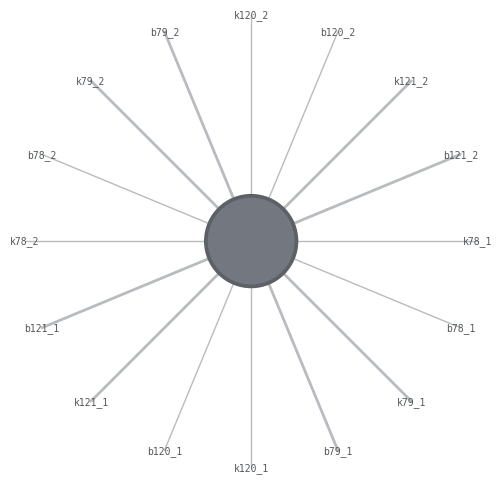

In [58]:
two_sided_environment_matrix.draw()

Split quatrit sites into qubit sites using multiplexers, demultiplexers.

In [115]:
np_demultiplixer_4_to_2_gate = np.array([
    [
        [1,0,0,0],
        [0,1,0,0],
    ],
    [
        [0,0,1,0],
        [0,0,0,1],
    ]
])

In [116]:
np_multiplixer_2_to_4_gate = np.array([
    [
        [1,0],
        [0,0],
    ],
    [
        [0,1],
        [0,0],
    ],
    [
        [0,0],
        [1,0],
    ],
    [
        [0,0],
        [0,1],
    ]
])

In [117]:
demultiplixer_4_to_2_gate = qtn.Tensor(data=np_demultiplixer_4_to_2_gate, inds=('k1', 'k2', 'b'))
multiplixer_2_to_4_gate = qtn.Tensor(data=np_multiplixer_2_to_4_gate, inds=('b', 'k1', 'k2'))

In [118]:
two_sided_environment_matrix

TensorNetwork(tensors=1, indices=16)

In [119]:
qubit_two_sided_environment_matrix = (
    two_sided_environment_matrix
    & demultiplixer_4_to_2_gate.reindex({'b': 'k79_2', 'k1': 'k79_1_2', 'k2': 'k79_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k121_2', 'k1': 'k121_1_2', 'k2': 'k121_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b79_2', 'k1': 'b79_1_2', 'k2': 'b79_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b121_2', 'k1': 'b121_1_2', 'k2': 'b121_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k79_1', 'k1': 'k79_1_1', 'k2': 'k79_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k121_1', 'k1': 'k121_1_1', 'k2': 'k121_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b79_1', 'k1': 'b79_1_1', 'k2': 'b79_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b121_1', 'k1': 'b121_1_1', 'k2': 'b121_2_1'})
) ^ ...

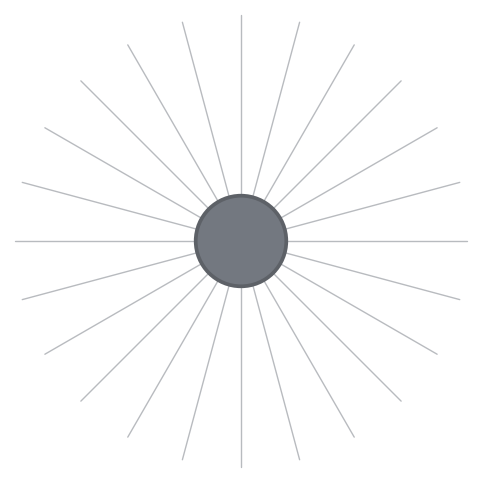

In [120]:
qubit_two_sided_environment_matrix.draw()

In [121]:
qubit_two_sided_environment_matrix

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k78_2', 'b78_2', 'k120_2', 'b120_2', 'k78_1', 'b78_1', 'k120_1', 'b120_1', 'k79_1_2', 'k79_2_2', 'k121_1_2', 'k121_2_2', 'b79_1_2', 'b79_2_2', 'b121_1_2', 'b121_2_2', 'k79_1_1', 'k79_2_1', 'k121_1_1', 'k121_2_1', 'b79_1_1', 'b79_2_1', 'b121_1_1', 'b121_2_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

### Initial boundary operator circuits

In [59]:
def single_qubit_layer(circ, gate_round=None):
    """Apply a parametrizable layer of single qubit ``U3`` gates.
    """
    for i in range(circ.N):
        # initialize with random parameters
        params = qu.randn(3, dist='uniform')
        circ.apply_gate(
            'U3',
            *params,
            i,
            gate_round=gate_round,
            parametrize=True
        )

In [60]:
def two_qubit_layer(circ, gate2='CZ', start=0, gate_round=None):
    """Apply a layer of constant entangling gates.
    """
    num_sites = circ.N # Assuming this is even
    sites = [
        i % num_sites
        for i in range(start, start + num_sites)
    ]
    
    site_pairs = list(zip(sites[::2], sites[1::2]))

    for i, j in site_pairs:
        circ.apply_gate(
            gate2,
            i,
            j,
            gate_round=gate_round
        )

In [62]:
def ansatz_circuit(n, depth, first_site=0, gate2='CZ',
                   gate_tag=None, **kwargs):
    """Construct a circuit of single qubit and entangling layers.
    """
    circ = qtn.Circuit(n, **kwargs)

    for r in range(depth):
        # single qubit gate layer
        single_qubit_layer(circ, gate_round=r)

        # alternate between forward and backward CZ layers
        two_qubit_layer(
            circ, gate2=gate2, gate_round=r, start=r % 2
        )

    # add a final single qubit layer
    single_qubit_layer(circ, gate_round=r + 1)

    circ = circ.get_uni(transposed=True)

    if gate_tag is not None:
        for t in circ.tensors:
            t.add_tag(gate_tag)

    if first_site != 0:
        index_labels = ['k', 'b']

        index_map = {
            f'{l}{i}': f'{l}{i+first_site}'
            for i in range(n)
            for l in index_labels
        }

        circ.reindex(index_map, inplace=True)

    return circ

In [68]:
left_circuit_1

TensorNetworkGenOperator(tensors=14, indices=19)

In [83]:
left_circuit_1 = ansatz_circuit(
    2,
    3,
    78
)

left_circuit_2 = ansatz_circuit(
    2,
    3,
    78
)

right_circuit_1 = ansatz_circuit(
    2,
    3,
    120
)

right_circuit_2 = ansatz_circuit(
    2,
    3,
    120
)

In [89]:
def partial_tranpose_objective(environment_matrix, left_circuit_1,
    left_circuit_2, right_circuit_1, right_circuit_2,
    left_symmetry_sites, right_symmetry_sites):

    rc_1 = (
        right_circuit_1
        .reindex({
            f'k{i}': f'b{i}_1' for i in right_symmetry_sites
        })
        .reindex({
            f'b{i}': f'k{i}_2' for i in right_symmetry_sites
        })
    )

    rc_2 = (
        right_circuit_2
        .reindex({
            f'k{i}': f'k{i}_1' for i in right_symmetry_sites
        })
        .reindex({
            f'b{i}': f'b{i}_2' for i in right_symmetry_sites
        })
    )

    lc_1 = (
        left_circuit_1
        .reindex({
            f'k{i}': f'b{i}_1' for i in left_symmetry_sites
        })
        .reindex({
            f'b{i}': f'k{i}_2' for i in left_symmetry_sites
        })
    )

    lc_2 = (
        left_circuit_2
        .reindex({
            f'k{i}': f'k{i}_1' for i in left_symmetry_sites
        })
        .reindex({
            f'b{i}': f'b{i}_2' for i in left_symmetry_sites
        })
    )

    a = (
        environment_matrix
        & rc_1
        & rc_2
        & lc_1
        & lc_2
    )

    return a

In [90]:
test = partial_tranpose_objective(
    two_sided_environment_matrix,
    left_circuit_1,
    left_circuit_2,
    right_circuit_1,
    right_circuit_2,
    [78, 79],
    [120, 121]
)

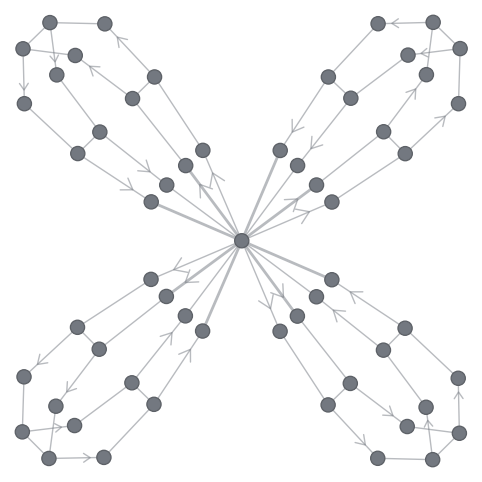

In [91]:
test.draw()

In [92]:
test

TensorNetwork(tensors=57, indices=76)

# Analysis

## Generate boundary operators

In [57]:
results = [
    find_boundary_operators(
        psi_dict[0],
        90,
        109,
        2,
        15
    )
    for _ in range(500)
]

In [58]:
len(results)

500

In [59]:
left_sims_1 = get_all_similarities(
    [l[0][0] for l in results]
)

(array([   44.,   189.,   725.,  1912.,  5277., 11830., 22224., 32119.,
        33355., 17075.]),
 array([1.19439882, 1.87456408, 2.55472934, 3.2348946 , 3.91505987,
        4.59522513, 5.27539039, 5.95555565, 6.63572092, 7.31588618,
        7.99605144]),
 <BarContainer object of 10 artists>)

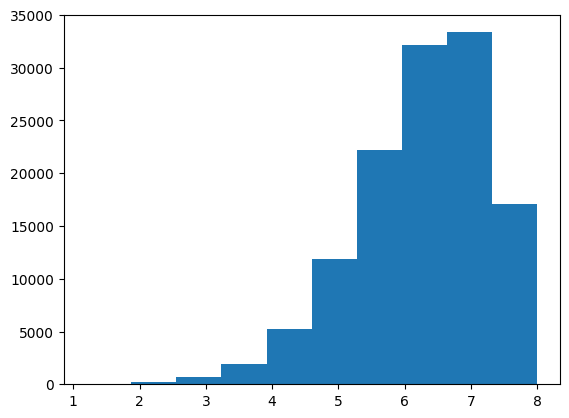

In [60]:
plt.hist(left_sims_1)

In [61]:
pd.Series(left_sims_1).describe()

count    124750.000000
mean          6.257509
std           0.992633
min           1.194399
25%           5.659549
50%           6.396324
75%           7.008337
max           7.996051
dtype: float64

In [62]:
left_sols_1 = np.array([l[0][0].data for l in results])    

In [83]:
left_sols_1 = left_sols_1.reshape((500, -1))

In [88]:
left_sols_1.shape

(500, 16)

In [84]:
np.linalg.matrix_rank(left_sols_1)

16

In [85]:
np.linalg.matrix_rank(left_sols_1.T)

16

In [87]:
np.linalg.svd(left_sols_1)[1]

array([13.02218193, 12.52419838, 12.32970984, 12.03149106, 11.87531923,
       11.71639184, 11.4642024 , 11.18059568, 10.99188129, 10.93593877,
       10.63577371, 10.40765079, 10.20925865,  9.94061282,  9.64402741,
        9.17338057])

In [69]:
results[0][0][0].data

array([[[[-0.32945911-0.40087129j,  0.65317012-0.12780495j],
         [-0.18307479+0.23100454j, -0.20815152-0.39697238j]],

        [[ 0.16664157+0.06605183j,  0.53903716+0.13452617j],
         [ 0.77603936-0.09751966j,  0.01231742+0.21750977j]]],


       [[[-0.48631602+0.1170103j ,  0.19367714+0.00938486j],
         [-0.14138022+0.17197281j,  0.71320364+0.39240789j]],

        [[-0.66031092-0.11145158j, -0.29864777+0.34869319j],
         [ 0.33487516-0.37372312j, -0.03603267-0.29611132j]]]])

In [89]:
left_sols_2 = np.array([l[0][0].data for l in results])    

In [94]:
left_sols_2 = left_sols_2.reshape((500, -1))

In [95]:
left_sols_2.shape

(500, 16)

In [96]:
left_sols = np.zeros((500, 16, 16), dtype='complex')

In [97]:
for i, (x1, x2) in enumerate(zip(left_sols_1, left_sols_2)):
    left_sols[i] = np.outer(x1, x2)

In [100]:
left_sols_flat = left_sols.reshape((500, -1))

In [101]:
np.linalg.matrix_rank(left_sols_flat)

136

In [103]:
np.linalg.svd(left_sols_flat)[1][120:140]

array([4.47758079e+00, 4.40636946e+00, 4.36743520e+00, 4.30899398e+00,
       4.26447899e+00, 4.20334013e+00, 4.10738373e+00, 4.04221705e+00,
       3.98357183e+00, 3.94995993e+00, 3.85921384e+00, 3.78286373e+00,
       3.73460823e+00, 3.63155404e+00, 3.61110733e+00, 3.46872918e+00,
       8.59941545e-15, 8.07356759e-15, 7.35773870e-15, 6.94053206e-15])

In [32]:
left_sims_2 = get_all_similarities(
    [l[0][1] for l in results]
)

(array([ 8., 11., 23., 29., 56., 84., 59., 67., 70., 28.]),
 array([3.62504048, 4.05758841, 4.49013633, 4.92268425, 5.35523217,
        5.78778009, 6.22032801, 6.65287594, 7.08542386, 7.51797178,
        7.9505197 ]),
 <BarContainer object of 10 artists>)

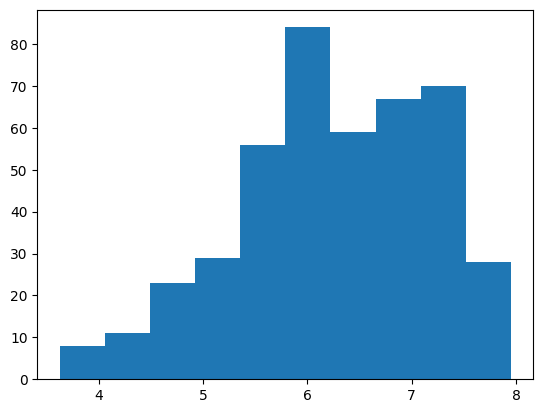

In [33]:
plt.hist(left_sims_2)

In [34]:
pd.Series(left_sims_2).describe()

count    435.000000
mean       6.260938
std        0.920011
min        3.625040
25%        5.674022
50%        6.293108
75%        7.001470
max        7.950520
dtype: float64

In [35]:
left_final_scores = [l[2][-1] for l in results]

In [36]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     1.000000e+00
std      3.123850e-12
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [37]:
right_sims_1 = get_all_similarities(
    [l[1][0] for l in results]
)

(array([ 1.,  5.,  8., 12., 24., 61., 72., 99., 93., 60.]),
 array([2.30515394, 2.86827926, 3.43140459, 3.99452992, 4.55765525,
        5.12078057, 5.6839059 , 6.24703123, 6.81015656, 7.37328188,
        7.93640721]),
 <BarContainer object of 10 artists>)

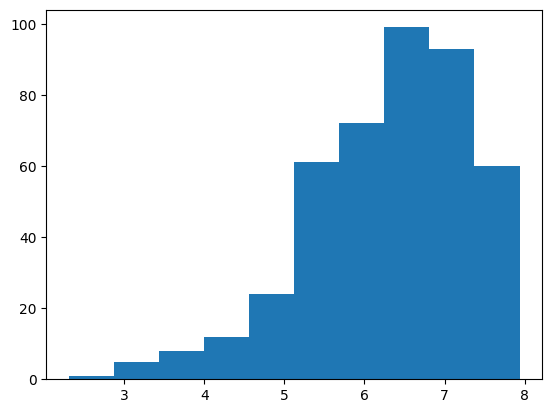

In [38]:
plt.hist(right_sims_1)

In [39]:
pd.Series(right_sims_1).describe()

count    435.000000
mean       6.301987
std        1.004483
min        2.305154
25%        5.666849
50%        6.399571
75%        7.088375
max        7.936407
dtype: float64

In [40]:
right_sims_2 = get_all_similarities(
    [l[1][1] for l in results]
)

(array([ 1.,  5.,  8., 12., 24., 61., 72., 99., 93., 60.]),
 array([2.30515394, 2.86827848, 3.43140302, 3.99452757, 4.55765211,
        5.12077666, 5.6839012 , 6.24702574, 6.81015029, 7.37327483,
        7.93639937]),
 <BarContainer object of 10 artists>)

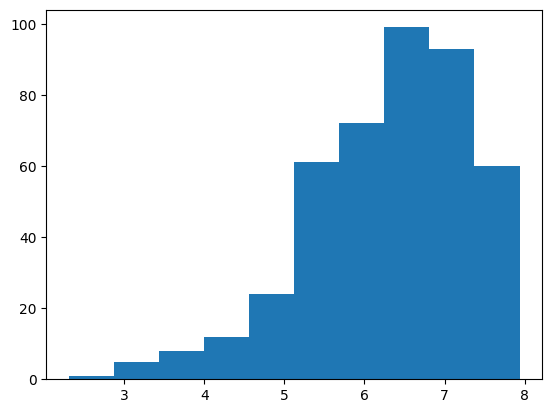

In [41]:
plt.hist(right_sims_2)

In [42]:
pd.Series(right_sims_2).describe()

count    435.000000
mean       6.301993
std        1.004478
min        2.305154
25%        5.667822
50%        6.399169
75%        7.088375
max        7.936399
dtype: float64

In [43]:
right_final_scores = [l[3][-1] for l in results]

In [44]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     1.000000e+00
std      3.123850e-12
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Take an example:

In [45]:
right_sims_1[0]

4.866721793521847

In [46]:
results[0][1][1].data

array([[[[ 0.28124128-0.03352534j, -0.55523794-0.31186076j],
         [ 0.2055276 -0.46919159j, -0.02870262-0.50102585j]],

        [[-0.05367906+0.42727391j, -0.1184251 -0.04442816j],
         [-0.47490336-0.4964065j ,  0.45630084+0.34408448j]]],


       [[[-0.50473922-0.24179041j,  0.44341688+0.06625911j],
         [-0.1429396 -0.32994438j,  0.20398387-0.56112608j]],

        [[ 0.37514006-0.52950978j,  0.32900031-0.51885j   ],
         [-0.33194657-0.16180697j, -0.11744329+0.22645056j]]]])

In [47]:
results[1][1][1].data

array([[[[-0.43447106-2.12823186e-01j, -0.09500256-7.96504741e-01j],
         [ 0.26182598+1.80889852e-01j,  0.10189   -1.04116962e-01j]],

        [[ 0.32749341-3.86922817e-01j, -0.31101534+1.35746915e-01j],
         [ 0.52406723+3.64773268e-01j, -0.2020863 +4.23480996e-01j]]],


       [[[ 0.13706838+1.75332758e-04j, -0.31458183+6.88940938e-02j],
         [-0.24298192+3.65690967e-01j,  0.82720757+2.14857458e-02j]],

        [[-0.47149427+5.17576435e-01j,  0.28674629+2.35510898e-01j],
         [ 0.21996691+4.99864456e-01j,  0.00402462+2.71758819e-01j]]]])

In [48]:
X1 = results[0][1][1].data
X2 = results[1][1][1].data

diffs = list()

for i in np.linspace(0, 1, 100):
    phase = np.exp(2*np.pi*1j*i)
    diffs.append(np.linalg.norm(X1 - phase*X2)**2)

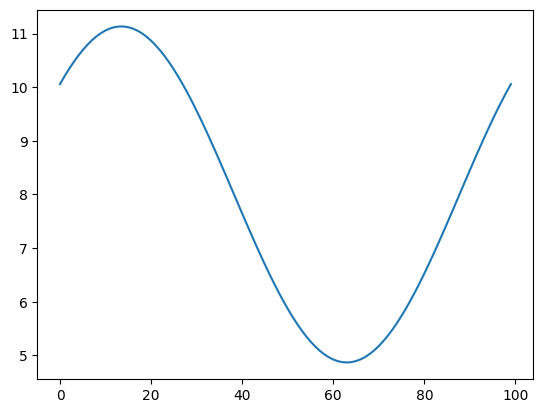

In [49]:
plt.plot(diffs)

In [50]:
np.min(diffs)

4.866734560970401

In [51]:
right_sims_2[0]

4.866721793521846

Consistent. So there is degeneracy. Dang.

## Compute "true" boundary operators.

In [52]:
def get_direct_environment_matrices(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites):
    
    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    psi_2 = psi.copy(deep=True)
    symmetry_tags = [f'I{i}' for i in symmetry_sites]
    for t in psi_2.select(symmetry_tags, which='any'):
        t.conj(inplace=True)

    psi_b = (
        psi
        .conj()
        .reindex({f'k{i}':f'b{i}' for i in all_sites})
    )

    x_gates = [
        x_gate.copy().reindex({'b': f'b{i}', 'k': f'k{i}'})
        for i in symmetry_sites
    ]
    
    leftright_env_matrix = (
        qtn.tensor_core.TensorNetwork(
            [
                psi_2,
                psi_b,
                *x_gates
            ]
        )
        .contract()
    )

    left_boundary_indices = [
        f'{bk}{i}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
    ]

    svd = leftright_env_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    left_right_singular_vals = svd.tensors[1].data

    left_env_matrix = svd.tensors[0].isel({'s': 0})
    right_env_matrix = svd.tensors[2].isel({'s': 0})

    return (left_env_matrix, right_env_matrix, left_right_singular_vals)

In [53]:
leftmost_symmetry_site = 60
rightmost_symmetry_site = 139
num_boundary_sites = 2

In [54]:
psi = psi_dict[0]

In [55]:
direct_env_matrices = get_direct_environment_matrices(
    psi,
    leftmost_symmetry_site,
    rightmost_symmetry_site,
    num_boundary_sites
)

In [56]:
direct_env_matrices

(Tensor(shape=(2, 2, 2, 2), inds=('b58', 'b59', 'k58', 'k59'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I12

In [57]:
np.round(direct_env_matrices[0].data, 3)

array([[[[-0. , -0.5],
         [ 0. , -0. ]],

        [[ 0.5, -0. ],
         [-0. , -0. ]]],


       [[[ 0. ,  0. ],
         [-0. ,  0.5]],

        [[ 0. , -0. ],
         [-0.5,  0. ]]]])

In [58]:
np.round(direct_env_matrices[1].data, 3)

array([[[[ 0. ,  0. ],
         [-0.5, -0. ]],

        [[ 0. ,  0. ],
         [ 0. ,  0.5]]],


       [[[ 0.5, -0. ],
         [-0. ,  0. ]],

        [[ 0. , -0.5],
         [-0. , -0. ]]]])

In [59]:
kb_transpose_dict = {
    'k': 'b',
    'b': 'k'
}

def tranpose_tensor_network(t):
    transpose_reindex_dict = {
        ind: kb_transpose_dict[ind[0]] + ind[1:]
        for ind in t.inds
    }

    return t.reindex(transpose_reindex_dict)

In [60]:
def hermitian_conjugate_tensor(t):
    return tranpose_tensor_network(t.conj())

In [61]:
def get_true_boundary_operator(environment_matrix):
    k_inds = [
        ind for ind in environment_matrix.inds
        if ind[0] == 'k'
    ]

    svd = environment_matrix.split(
        left_inds=k_inds,
        absorb=None,
        bond_ind='s'
    )

    boundary_op_hc = (svd.tensors[0] & svd.tensors[2])^...
    boundary_op = hermitian_conjugate_tensor(boundary_op_hc)

    return boundary_op

In [62]:
left_boundary_op = get_true_boundary_operator(direct_env_matrices[0])
right_boundary_op = get_true_boundary_operator(direct_env_matrices[1])

In [63]:
left_boundary_op

Tensor(shape=(2, 2, 2, 2), inds=('b58', 'b59', 'k58', 'k59'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141', 'I142', 'I143', 'I144', 'I145', 'I146', 'I147', 'I148', 'I149', 'I150', 'I151', 'I152', 'I153', 'I154', 'I155', 'I156', 'I157', 'I158', 'I159', 'I160', 'I161', 'I162', 'I163', 'I164', 'I165', 'I166', 'I167', 'I168', 'I169', 'I170', 'I171', 'I172', 'I173', 'I174', 'I175', 'I176', 'I177', 'I178', 'I179', 'I180', 'I181', 'I182', 'I183', 'I184', 'I185', 'I186', 'I187', 'I188', 'I189', 'I190', 'I191', 'I192', 'I193', 'I194', 'I195', 'I196', 'I197', 'I198', 'I199']))

In [64]:
np.round(left_boundary_op.data, 3)

array([[[[-0.,  1.],
         [ 0., -0.]],

        [[-1., -0.],
         [ 0., -0.]]],


       [[[ 0., -0.],
         [-0., -1.]],

        [[ 0.,  0.],
         [ 1., -0.]]]])

In [65]:
np.round(tranpose_tensor_network(left_boundary_op).data, 3)

array([[[[-0.,  1.],
         [ 0., -0.]],

        [[-1., -0.],
         [ 0., -0.]]],


       [[[ 0., -0.],
         [-0., -1.]],

        [[ 0.,  0.],
         [ 1., -0.]]]])

In [66]:
right_boundary_op

Tensor(shape=(2, 2, 2, 2), inds=('b140', 'b141', 'k140', 'k141'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141', 'I142', 'I143', 'I144', 'I145', 'I146', 'I147', 'I148', 'I149', 'I150', 'I151', 'I152', 'I153', 'I154', 'I155', 'I156', 'I157', 'I158', 'I159', 'I160', 'I161', 'I162', 'I163', 'I164', 'I165', 'I166', 'I167', 'I168', 'I169', 'I170', 'I171', 'I172', 'I173', 'I174', 'I175', 'I176', 'I177', 'I178', 'I179', 'I180', 'I181', 'I182', 'I183', 'I184', 'I185', 'I186', 'I187', 'I188', 'I189', 'I190', 'I191', 'I192', 'I193', 'I194', 'I195', 'I196', 'I197', 'I198', 'I199']))

In [67]:
np.round(right_boundary_op.data, 3)

array([[[[ 0., -0.],
         [-1., -0.]],

        [[-0.,  0.],
         [-0.,  1.]]],


       [[[ 1.,  0.],
         [ 0., -0.]],

        [[ 0., -1.],
         [ 0.,  0.]]]])

Looks right to me.

In [68]:
np.round(tranpose_tensor_network(right_boundary_op).data, 3)

array([[[[ 0., -0.],
         [-1., -0.]],

        [[-0.,  0.],
         [-0.,  1.]]],


       [[[ 1.,  0.],
         [ 0., -0.]],

        [[ 0., -1.],
         [ 0.,  0.]]]])

Both boundary operators are conjugation and transposition invariant, so don't need to worry about orientation plugging into to the partial transpose environment matrices.

In [69]:
symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
all_sites = list(range(
    leftmost_symmetry_site-num_boundary_sites,
    rightmost_symmetry_site+1+num_boundary_sites
))

rho = psi.partial_trace_to_mpo(
    all_sites,
    rescale_sites=False
)

rho_2 = rho.copy()

rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in symmetry_sites
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in symmetry_sites
]

two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)
two_sided_environment_matrix.contract(inplace=False)

left_boundary_sites = list(range(
    leftmost_symmetry_site-num_boundary_sites,
    leftmost_symmetry_site
))

right_boundary_sites = list(range(
    rightmost_symmetry_site+1,
    rightmost_symmetry_site+1+num_boundary_sites
))

left_boundary_indices = [
    f'{bk}{i}_{j}'
    for bk in ['b', 'k']
    for i in left_boundary_sites
    for j in [1, 2]
]

split_two_sided_environment_matrix = two_sided_environment_matrix.split(
    left_inds=left_boundary_indices,
    absorb=None,
    bond_ind='s'
)

two_sided_sing_vals = (
    split_two_sided_environment_matrix
    .tensors[1]
    .data
)

left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

In [70]:
left_env_matrix

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('b58_1', 'b58_2', 'b59_1', 'b59_2', 'k58_1', 'k58_2', 'k59_1', 'k59_2'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

In [71]:
def add_subscript_to_tensor_inds(t, subscript):
    index_map = {
        ind: f'{ind}_{subscript}' for ind in t.inds
    }

    out = t.reindex(index_map)

    return out

In [72]:
def add_kb_subscript_to_tensor_inds(t, k_subscript, b_subscript):
    k_index_map = {
        ind: f'{ind}_{k_subscript}' for ind in t.inds
        if ind[0] == 'k'
    }

    b_index_map = {
        ind: f'{ind}_{b_subscript}' for ind in t.inds
        if ind[0] == 'b'
    }

    out = (
        t
        .reindex(k_index_map)
        .reindex(b_index_map)
    )

    return out

In [73]:
(
    left_env_matrix
    & add_kb_subscript_to_tensor_inds(left_boundary_op, '1', '2')
    & add_kb_subscript_to_tensor_inds(left_boundary_op, '2', '1')
) ^...

-1.0

In [74]:
(
    right_env_matrix
    & add_kb_subscript_to_tensor_inds(right_boundary_op, '1', '2')
    & add_kb_subscript_to_tensor_inds(right_boundary_op, '2', '1')
) ^...

-1.0000000000000002

So the boundary operators do indeed optimize. There are just other possible solutions.

## Plug in partial transpose boundary operators to direct environment matrices

In [75]:
(direct_env_matrices[0] & left_boundary_op)^...

-2.0

In [76]:
(direct_env_matrices[1] & right_boundary_op)^...

-2.0

In [77]:
def clean_op_indices(op_t):
    clean_reindex_dict = {
        ind: ('').join(ind.split('_')[:-1])
        for ind in op_t.inds
    }

    return op_t.reindex(clean_reindex_dict)

In [78]:
results[0][1][0]

Tensor(shape=(2, 2, 2, 2), inds=('k140_1', 'k141_1', 'b140_2', 'b141_2'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

In [79]:
pt_op_in_right_direct_env_scores = list()

for l in results:
    ops = l[1]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[1]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_right_direct_env_scores.append(scores)

In [80]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.618, 0.618, 0.618, 0.618],
       [0.618, 0.618, 0.618, 0.618],
       [0.307, 0.307, 0.307, 0.307],
       [0.307, 0.307, 0.307, 0.307],
       [0.038, 0.038, 0.038, 0.038],
       [0.038, 0.038, 0.038, 0.038],
       [0.758, 0.758, 0.758, 0.758],
       [0.758, 0.758, 0.758, 0.758],
       [0.636, 0.636, 0.636, 0.636],
       [0.636, 0.636, 0.636, 0.636],
       [0.011, 0.011, 0.011, 0.011],
       [0.011, 0.011, 0.011, 0.011],
       [0.314, 0.314, 0.314, 0.314],
       [0.314, 0.314, 0.314, 0.314],
       [0.099, 0.099, 0.099, 0.099],
       [0.099, 0.099, 0.099, 0.099],
       [0.162, 0.162, 0.162, 0.162],
       [0.162, 0.162, 0.162, 0.162],
       [0.081, 0.081, 0.081, 0.081],
       [0.081, 0.081, 0.081, 0.081],
       [1.096, 1.096, 1.096, 1.096],
       [1.096, 1.096, 1.096, 1.096],
       [0.341, 0.341, 0.341, 0.341],
       [0.341, 0.341, 0.341, 0.341],
       [0.666, 0.666, 0.666, 0.666],
       [0.666, 0.666, 0.666, 0.666],
       [0.146, 0.146, 0.146, 0.146],
 

In [81]:
pt_op_in_left_direct_env_scores = list()

for l in results:
    ops = l[0]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[0]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_left_direct_env_scores.append(scores)

In [82]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.618, 0.618, 0.618, 0.618],
       [0.618, 0.618, 0.618, 0.618],
       [0.307, 0.307, 0.307, 0.307],
       [0.307, 0.307, 0.307, 0.307],
       [0.038, 0.038, 0.038, 0.038],
       [0.038, 0.038, 0.038, 0.038],
       [0.758, 0.758, 0.758, 0.758],
       [0.758, 0.758, 0.758, 0.758],
       [0.636, 0.636, 0.636, 0.636],
       [0.636, 0.636, 0.636, 0.636],
       [0.011, 0.011, 0.011, 0.011],
       [0.011, 0.011, 0.011, 0.011],
       [0.314, 0.314, 0.314, 0.314],
       [0.314, 0.314, 0.314, 0.314],
       [0.099, 0.099, 0.099, 0.099],
       [0.099, 0.099, 0.099, 0.099],
       [0.162, 0.162, 0.162, 0.162],
       [0.162, 0.162, 0.162, 0.162],
       [0.081, 0.081, 0.081, 0.081],
       [0.081, 0.081, 0.081, 0.081],
       [1.096, 1.096, 1.096, 1.096],
       [1.096, 1.096, 1.096, 1.096],
       [0.341, 0.341, 0.341, 0.341],
       [0.341, 0.341, 0.341, 0.341],
       [0.666, 0.666, 0.666, 0.666],
       [0.666, 0.666, 0.666, 0.666],
       [0.146, 0.146, 0.146, 0.146],
 

So they're not reaching as high as they could be...

## Alternative cost function

In [84]:
results = [
    find_boundary_operators_2(
        psi_dict[0],
        60,
        139,
        2,
        20
    )
    for _ in range(30)
]

In [85]:
len(results)

30

In [86]:
left_sims_1 = get_all_similarities(
    [l[0][0] for l in results]
)

(array([17., 26., 33., 46., 37., 59., 58., 57., 56., 46.]),
 array([0.14920646, 0.9329597 , 1.71671294, 2.50046618, 3.28421942,
        4.06797266, 4.8517259 , 5.63547914, 6.41923238, 7.20298562,
        7.98673886]),
 <BarContainer object of 10 artists>)

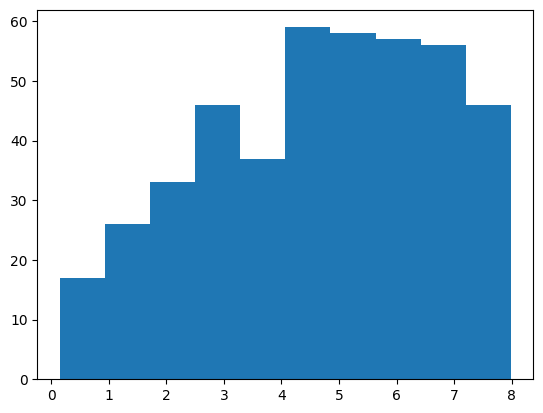

In [87]:
plt.hist(left_sims_1)

In [88]:
pd.Series(left_sims_1).describe()

count    435.000000
mean       4.655997
std        2.024628
min        0.149206
25%        3.151282
50%        4.849145
75%        6.317005
max        7.986739
dtype: float64

In [89]:
left_sims_2 = get_all_similarities(
    [l[0][1] for l in results]
)

(array([17., 26., 33., 46., 37., 59., 58., 57., 56., 46.]),
 array([0.14920646, 0.9329597 , 1.71671294, 2.50046618, 3.28421942,
        4.06797266, 4.8517259 , 5.63547914, 6.41923238, 7.20298562,
        7.98673886]),
 <BarContainer object of 10 artists>)

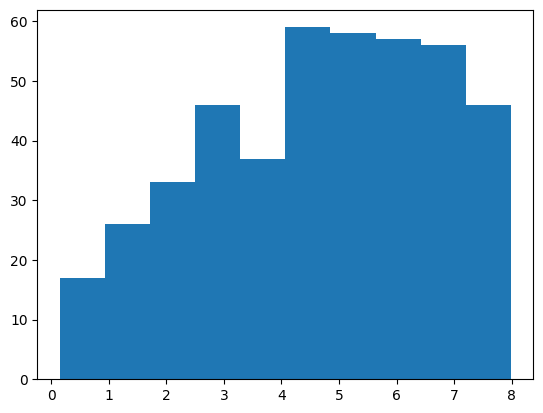

In [90]:
plt.hist(left_sims_2)

In [91]:
pd.Series(left_sims_2).describe()

count    435.000000
mean       4.655997
std        2.024628
min        0.149206
25%        3.151282
50%        4.849145
75%        6.317005
max        7.986739
dtype: float64

In [92]:
left_final_scores = [l[2][-1] for l in results]

In [93]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     2.000000e+00
std      6.787751e-16
min      2.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      2.000000e+00
dtype: float64

In [94]:
right_sims_1 = get_all_similarities(
    [l[1][0] for l in results]
)

(array([15., 25., 37., 55., 43., 40., 66., 50., 55., 49.]),
 array([0.10542941, 0.89293878, 1.68044816, 2.46795753, 3.2554669 ,
        4.04297627, 4.83048565, 5.61799502, 6.40550439, 7.19301376,
        7.98052314]),
 <BarContainer object of 10 artists>)

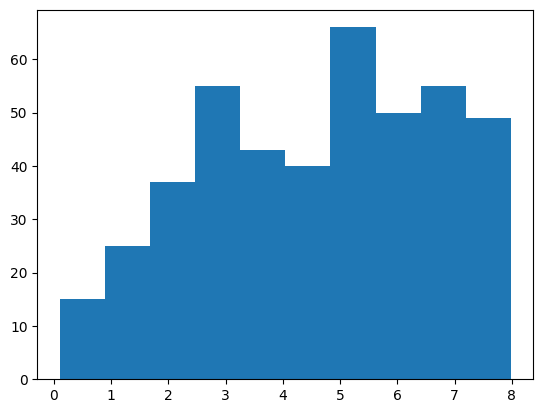

In [95]:
plt.hist(right_sims_1)

In [96]:
pd.Series(right_sims_1).describe()

count    435.000000
mean       4.606447
std        2.049216
min        0.105429
25%        2.990689
50%        4.855227
75%        6.231107
max        7.980523
dtype: float64

In [97]:
right_sims_2 = get_all_similarities(
    [l[1][1] for l in results]
)

(array([15., 25., 37., 55., 43., 40., 66., 50., 55., 49.]),
 array([0.10542941, 0.89293878, 1.68044816, 2.46795753, 3.2554669 ,
        4.04297627, 4.83048565, 5.61799502, 6.40550439, 7.19301376,
        7.98052314]),
 <BarContainer object of 10 artists>)

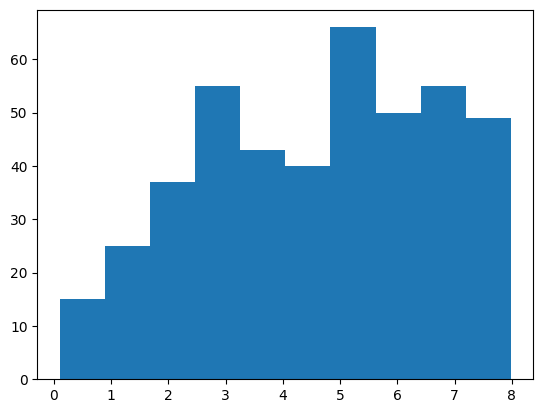

In [98]:
plt.hist(right_sims_2)

In [99]:
pd.Series(right_sims_2).describe()

count    435.000000
mean       4.606447
std        2.049216
min        0.105429
25%        2.990689
50%        4.855227
75%        6.231107
max        7.980523
dtype: float64

In [102]:
pt_op_in_right_direct_env_scores = list()

for l in results:
    ops = l[1]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[1]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_right_direct_env_scores.append(scores)

In [103]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.944, 0.944, 0.944, 0.944],
       [0.944, 0.944, 0.944, 0.944],
       [0.585, 0.585, 0.585, 0.585],
       [0.585, 0.585, 0.585, 0.585],
       [0.822, 0.822, 0.822, 0.822],
       [0.822, 0.822, 0.822, 0.822],
       [0.954, 0.954, 0.954, 0.954],
       [0.954, 0.954, 0.954, 0.954],
       [0.313, 0.313, 0.313, 0.313],
       [0.313, 0.313, 0.313, 0.313],
       [1.417, 1.417, 1.417, 1.417],
       [1.417, 1.417, 1.417, 1.417],
       [0.614, 0.614, 0.614, 0.614],
       [0.614, 0.614, 0.614, 0.614],
       [0.688, 0.688, 0.688, 0.688],
       [0.688, 0.688, 0.688, 0.688],
       [1.147, 1.147, 1.147, 1.147],
       [1.147, 1.147, 1.147, 1.147],
       [1.721, 1.721, 1.721, 1.721],
       [1.721, 1.721, 1.721, 1.721],
       [0.109, 0.109, 0.109, 0.109],
       [0.109, 0.109, 0.109, 0.109],
       [1.309, 1.309, 1.309, 1.309],
       [1.309, 1.309, 1.309, 1.309],
       [0.213, 0.213, 0.213, 0.213],
       [0.213, 0.213, 0.213, 0.213],
       [0.38 , 0.38 , 0.38 , 0.38 ],
 

In [104]:
pt_op_in_left_direct_env_scores = list()

for l in results:
    ops = l[0]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[0]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_left_direct_env_scores.append(scores)

In [105]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.944, 0.944, 0.944, 0.944],
       [0.944, 0.944, 0.944, 0.944],
       [0.585, 0.585, 0.585, 0.585],
       [0.585, 0.585, 0.585, 0.585],
       [0.822, 0.822, 0.822, 0.822],
       [0.822, 0.822, 0.822, 0.822],
       [0.954, 0.954, 0.954, 0.954],
       [0.954, 0.954, 0.954, 0.954],
       [0.313, 0.313, 0.313, 0.313],
       [0.313, 0.313, 0.313, 0.313],
       [1.417, 1.417, 1.417, 1.417],
       [1.417, 1.417, 1.417, 1.417],
       [0.614, 0.614, 0.614, 0.614],
       [0.614, 0.614, 0.614, 0.614],
       [0.688, 0.688, 0.688, 0.688],
       [0.688, 0.688, 0.688, 0.688],
       [1.147, 1.147, 1.147, 1.147],
       [1.147, 1.147, 1.147, 1.147],
       [1.721, 1.721, 1.721, 1.721],
       [1.721, 1.721, 1.721, 1.721],
       [0.109, 0.109, 0.109, 0.109],
       [0.109, 0.109, 0.109, 0.109],
       [1.309, 1.309, 1.309, 1.309],
       [1.309, 1.309, 1.309, 1.309],
       [0.213, 0.213, 0.213, 0.213],
       [0.213, 0.213, 0.213, 0.213],
       [0.38 , 0.38 , 0.38 , 0.38 ],
 

In [100]:
right_final_scores = [l[3][-1] for l in results]

# Conclusions
It looks like the partial transpose boundary operators form a superset of the true boundary operators. Need to find another optimisation function!